In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.tri as mtri
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import ascii
import pandas as pd
import networkx as nx
import scipy
import seaborn as sns
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import os
from collections import Counter
from concurrent.futures import ProcessPoolExecutor

In [ ]:
def dict_data(n_random, numero, start_index=0):
    data = {}
    rand = {}
    for i in range(n_random):
        file_index = start_index + i
        table = Table.read(
            f"/content/drive/MyDrive/DESI/classification/LRG_NGC_{numero}_random_{file_index}_filt.fits"
        ).to_pandas()

        table['type'] = table['type'].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
        table[f'class_{file_index}'] = table[f'class_{file_index}'].apply(
            lambda x: x.decode() if isinstance(x, bytes) else x
        )

        data[file_index] = dict(zip(table[table['type']=='data']['TARGETID'],
                                    table[table['type']=='data'][f'class_{file_index}']))
        rand[file_index] = dict(zip(table[table['type']=='rand']['TARGETID'],
                                    table[table['type']=='rand'][f'class_{file_index}']))
    return data, rand

In [ ]:
l = dict_data(1,1)

In [ ]:
len(l[0][0])

728582

In [ ]:
def classes(n_random, data):
    dict_classes = {}

    for subdict in data.values():
        for tid, clase in subdict.items():
            if tid not in dict_classes:
                dict_classes[tid] = []
            dict_classes[tid].append(clase)

    return dict_classes

In [ ]:
def compute_entropy(class_dict, n_random):
    entropy_result = {}
    probs_result = {}
    total = n_random
    for tid, class_list in class_dict.items():
        counts = Counter(class_list)
        p = np.array([
            counts.get('filament', 0) / total,
            counts.get('sheet', 0) / total,
            counts.get('void', 0) / total,
            counts.get('knot', 0) / total
        ])

        terms = np.where(p > 0, p * np.log2(p), 0)

        h = np.abs(-(np.sum(terms)) / np.log2(4))

        entropy_result[tid] = h

    return entropy_result

In [ ]:
def process_in_chunks_entropy(n_total, numero, chunk_size=10):
    dict_classes_data_total = {}

    for start in range(0, n_total, chunk_size):
        end = min(start + chunk_size, n_total)
        print(f"Procesando random {start} a {end-1}")

        data_chunk, _ = dict_data(n_random=(end - start), numero=numero, start_index=start)

        dict_classes_data_chunk = classes(end - start, data_chunk)

        for tid, class_list in dict_classes_data_chunk.items():
            dict_classes_data_total.setdefault(tid, []).extend(class_list)

        del data_chunk, dict_classes_data_chunk
        import gc; gc.collect()

    print(len(dict_classes_data_total))
    entropy_data = compute_entropy(dict_classes_data_total, n_total)
    return entropy_data

In [ ]:
%%time
entropy_data1 = process_in_chunks_entropy(n_total=100, numero=1, chunk_size=5)

Procesando random 0 a 4
Procesando random 5 a 9
Procesando random 10 a 14
Procesando random 15 a 19
Procesando random 20 a 24
Procesando random 25 a 29
Procesando random 30 a 34
Procesando random 35 a 39
Procesando random 40 a 44
Procesando random 45 a 49
Procesando random 50 a 54
Procesando random 55 a 59
Procesando random 60 a 64
Procesando random 65 a 69
Procesando random 70 a 74
Procesando random 75 a 79
Procesando random 80 a 84
Procesando random 85 a 89
Procesando random 90 a 94
Procesando random 95 a 99
728582


/tmp/ipython-input-8-3802138540.py:14: RuntimeWarning: divide by zero encountered in log2
  terms = np.where(p > 0, p * np.log2(p), 0)
/tmp/ipython-input-8-3802138540.py:14: RuntimeWarning: invalid value encountered in multiply
  terms = np.where(p > 0, p * np.log2(p), 0)


CPU times: user 8min 41s, sys: 31.8 s, total: 9min 13s
Wall time: 11min 37s


In [ ]:
%%time
entropy_data2 = process_in_chunks_entropy(n_total=100, numero=2, chunk_size=5)

Procesando random 0 a 4
Procesando random 5 a 9
Procesando random 10 a 14
Procesando random 15 a 19
Procesando random 20 a 24
Procesando random 25 a 29
Procesando random 30 a 34
Procesando random 35 a 39
Procesando random 40 a 44
Procesando random 45 a 49
Procesando random 50 a 54
Procesando random 55 a 59
Procesando random 60 a 64
Procesando random 65 a 69
Procesando random 70 a 74
Procesando random 75 a 79
Procesando random 80 a 84
Procesando random 85 a 89
Procesando random 90 a 94
Procesando random 95 a 99
200062


/tmp/ipython-input-8-3802138540.py:14: RuntimeWarning: divide by zero encountered in log2
  terms = np.where(p > 0, p * np.log2(p), 0)
/tmp/ipython-input-8-3802138540.py:14: RuntimeWarning: invalid value encountered in multiply
  terms = np.where(p > 0, p * np.log2(p), 0)


CPU times: user 4min 13s, sys: 8.07 s, total: 4min 21s
Wall time: 6min 18s


In [ ]:
df_entropy1 = pd.DataFrame(columns=['TARGETID', 'entropy'])
df_entropy2 = pd.DataFrame(columns=['TARGETID', 'entropy'])

df_entropy1['entropy'] = list(entropy_data1.values())
df_entropy1['TARGETID'] = list(entropy_data1.keys())
df_entropy2['entropy'] = list(entropy_data2.values())
df_entropy2['TARGETID'] = list(entropy_data2.keys())

table_entropy1 = Table.from_pandas(df_entropy1)
table_entropy2 = Table.from_pandas(df_entropy2)
filename1 = f"/content/drive/MyDrive/DESI/entropy/LRG_entropy_NGC_1.ecsv"
filename2 = f"/content/drive/MyDrive/DESI/entropy/LRG_entropy_NGC_2.ecsv"
ascii.write(table_entropy1, filename1, format='ecsv', overwrite=True)
ascii.write(table_entropy2, filename2, format='ecsv', overwrite=True)

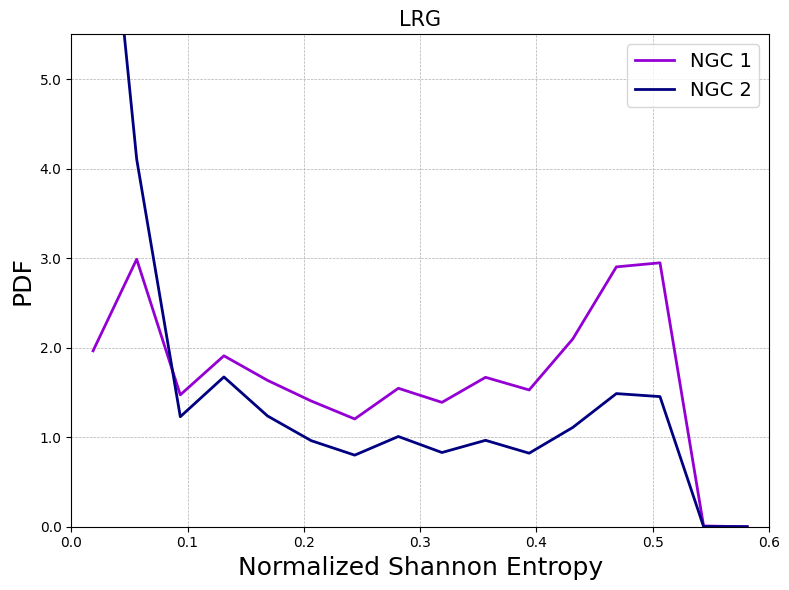

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

bins = 16

hist, bin_edges = np.histogram(df_entropy1['entropy'], bins=bins, range=(0, 0.6), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, hist, linewidth=2, color='darkviolet', label='NGC 1')

hist, bin_edges = np.histogram(df_entropy2['entropy'], bins=bins, range=(0, 0.6), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, hist, linewidth=2, color='navy', label='NGC 2')

ax.set_xlabel(r"Normalized Shannon Entropy", fontsize=18)
ax.set_ylabel("PDF", fontsize=18)
ax.set_xlim(0, 0.6)
ax.set_ylim([0, 5.5])
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
ax.grid(True, linestyle='--', linewidth=0.5)

ax.legend(fontsize=14)
plt.title('LRG',size=15)
plt.tight_layout()
plt.show()